## 🔹 Imports

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pandas as pd

np.random.seed(13)

## 🔹Parametros Gerais e Função Objetivo

In [20]:
# Parâmetros
n_vars = 10
lower, upper = -5.12, 5.12

pop_size = 100
max_evaluations = 100000

# ======= Função objetivo (Rastrigin) =============
def rastrigin(x):
    n = len(x)
    return 10*n + sum(xi**2 - 10*np.cos(2*np.pi*xi) for xi in x)


# Função para plotar a população projetada em 2D
def plot_population_2d_slice(pop, ref=None, dims=(0,1), generation=None,
                            lower=-5.12, upper=5.12, resolution=120,
                            show_best=True, title_prefix=""):
    clear_output(wait=True)
    import numpy as np
    import matplotlib.pyplot as plt

    d1, d2 = dims

    if ref is None:
        ref = np.zeros(n_vars) 
    else:
        ref = ref.copy()

    x = np.linspace(lower, upper, resolution)
    y = np.linspace(lower, upper, resolution)
    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            vec = ref.copy()
            vec[d1] = X[i, j]
            vec[d2] = Y[i, j]
            Z[i, j] = rastrigin(vec)

    plt.figure(figsize=(6,6))
    plt.contour(X, Y, Z, levels=25, colors='black', linewidths=0.5)

    # População no plano (d1,d2)
    plt.scatter(pop[:, d1], pop[:, d2], color='red', s=10, alpha=0.6, label="pop")

    if show_best:
        fitness_vals = np.array([rastrigin(ind) for ind in pop])
        best = pop[np.argmin(fitness_vals)]
        plt.scatter(best[d1], best[d2], facecolors='blue', s=40, edgecolors='black', label="best")

    if generation is not None:
        plt.title(f"{title_prefix} Geração {generation}")

    plt.xlabel(f"x{d1+1}")
    plt.ylabel(f"x{d2+1}")
    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.show()

## 🔹 Resolução 1 - Algoritmo DE (Differential Evolution)

In [7]:
# Parâmetros fixos DE
F = 0.8
CR = 0.5
lambda_ = 0.9

# Inicialização
def init_population():
    return np.random.uniform(lower, upper, (pop_size, n_vars))

# Avaliação
def evaluate_population(pop):
    return np.array([rastrigin(ind) for ind in pop])

# Loop principal
def differential_evolution():  #DE/current-to-best/1/bin (com λ)
    pop = init_population()
    
    # Avaliação inicial
    fitness = evaluate_population(pop)
    total_evals = pop_size
    
    generation = 0

    best_history = []
    avg_history = []

    tol = 1e-3  

    print("Iniciando DE...")

    while total_evals < max_evaluations:

        best_fit = np.min(fitness)
        best_history.append(best_fit)
        avg_history.append(np.mean(fitness))

        if best_fit <= tol:
            print(f"Parada antecipada: atingiu tolerância (f <= {tol})")
            break

        new_pop = []
        new_fitness = []

        for i in range(pop_size):
            if total_evals >= max_evaluations:
                break

            # Seleção de índices
            idxs = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(idxs, 3, replace=False)

            # Mutação
            best = pop[np.argmin(fitness)]
            mutant = pop[i] + lambda_*(best - pop[i]) + F*(pop[r2] - pop[r3])
            mutant = np.clip(mutant, lower, upper)

            # Crossover
            trial = np.copy(pop[i])
            j_rand = np.random.randint(n_vars)

            for j in range(n_vars):
                if np.random.rand() < CR or j == j_rand:
                    trial[j] = mutant[j]

            # Avaliação
            trial_fit = rastrigin(trial)
            total_evals += 1

            if trial_fit <= tol:
                print(f"Parada antecipada dentro da geração {generation}")
                return best_history, avg_history, np.array([trial]), generation, True

            # Seleção
            if trial_fit <= fitness[i]:
                new_pop.append(trial)
                new_fitness.append(trial_fit)
            else:
                new_pop.append(pop[i])
                new_fitness.append(fitness[i])

        pop = np.array(new_pop)
        fitness = np.array(new_fitness)

        if generation % 50 == 0:
            print(f"Gen {generation} | Evals: {total_evals} | Best: {best_fit:.6f}")
            plot_population_2d_slice(pop, ref=best, generation=generation, title_prefix="DE -")

        generation += 1
    best_fit = np.min(fitness)
    return best_history, avg_history, pop, generation, best_fit <= tol

### 🔹 1.1 Execução e plot - DE 

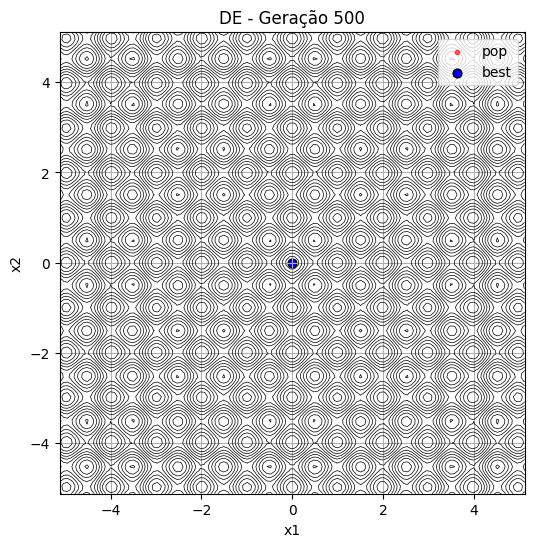

Parada antecipada dentro da geração 509

Tabela de Resultados:
   Execução  Convergiu  Gerações  Melhor f(x)
0         1       True       581     0.000982
1         2       True       526     0.000823
2         3       True       451     0.000856
3         4       True       551     0.000775
4         5       True       625     0.000997
5         6       True       624     0.000980
6         7       True       494     0.000804
7         8       True       416     0.000879
8         9       True       483     0.000774
9        10       True       509     0.000960

--- Estatísticas ---
Taxa de sucesso: 100.0%
Melhor valor: 0.000774
Média: 0.000883


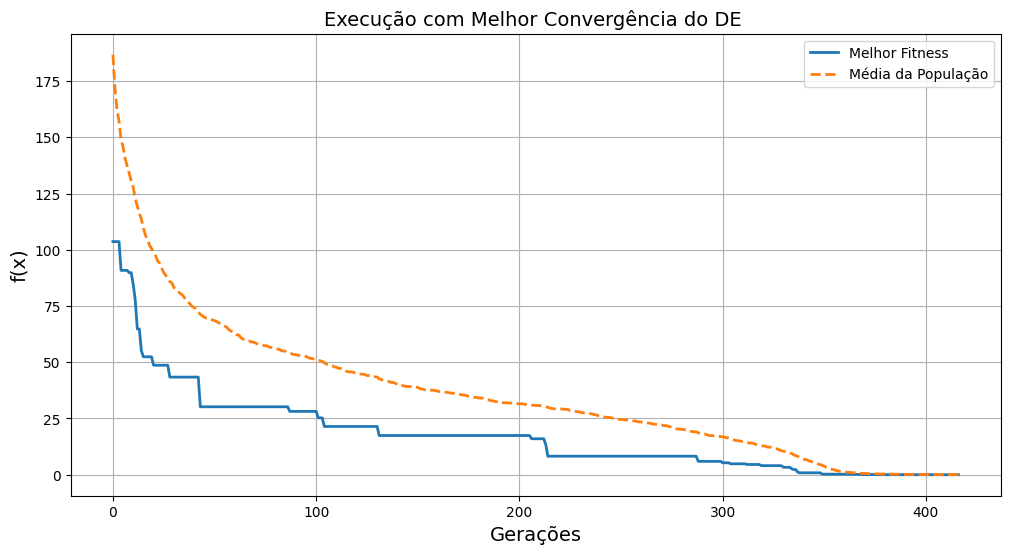

In [45]:
# loop de execuções
n_runs = 10
results = []
histories = []

for run in range(n_runs):
    print(f"\nExecução {run+1}/{n_runs}")

    best_hist, avg_hist, final_pop, n_gen, converged = differential_evolution()

    fitness_final = evaluate_population(final_pop)
    best_value = np.min(fitness_final)

    results.append({
        "Execução": run + 1,
        "Convergiu": converged,
        "Gerações": n_gen,
        "Melhor f(x)": best_value
    })

    histories.append({
        "best": best_hist,
        "avg": avg_hist,
        "gen": n_gen,
        "best_value": best_value,
        "converged": converged
    })

# tabela de resultados
df = pd.DataFrame(results)
print("\nTabela de Resultados:")
print(df)

# estatísticas
success_rate = df["Convergiu"].mean()
best_overall = df["Melhor f(x)"].min()
mean_value = df["Melhor f(x)"].mean()
print("\n--- Estatísticas ---")
print(f"Taxa de sucesso: {success_rate*100:.1f}%")
print(f"Melhor valor: {best_overall:.6f}")
print(f"Média: {mean_value:.6f}")

# Plot da melhor execução
valid_runs = [h for h in histories if h["converged"]]
if len(valid_runs) > 0:
    best_run = min(valid_runs, key=lambda x: x["gen"])
else:
    best_run = min(histories, key=lambda x: x["best_value"])
plt.figure(figsize=(12,6))
plt.plot(best_run["best"], label="Melhor Fitness",linewidth=2)
plt.plot(best_run["avg"], label="Média da População", linestyle='--', linewidth=2)

# plt.yscale('log') 
plt.xlabel("Gerações", fontsize=14)
plt.ylabel("f(x)", fontsize=14)
plt.title("Execução com Melhor Convergência do DE ", fontsize=14)
plt.legend()
plt.grid()

plt.show()

## 🔹2 Resolução com PSO (Particle Swarm Optimization)

In [38]:
# Parâmetros fixos PSO
w_max = 0.85             # exploração no começo
w_min = 0.5              # refino no fim
c1 = 1.9                 # componente cognitiva/ memoria individual
c2 = 1.75                # componente social / pressão do grupo

# Inicialização
def init_swarm():
    pos = np.random.uniform(lower, upper, (pop_size, n_vars))
    vel = np.random.uniform(-1, 1, (pop_size, n_vars))
    return pos, vel

# Avaliação
def evaluate_population(pop):
    return np.array([rastrigin(ind) for ind in pop])

# Loop principal
def pso():
    pos, vel = init_swarm()
    generation = 0

    # Avaliação inicial
    fitness = evaluate_population(pos)
    total_evals = pop_size
    tol=1e-3
    pbest = pos.copy()
    pbest_fit = fitness.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    best_history = []
    avg_history = []

    print("Iniciando PSO ...")

    while total_evals < max_evaluations:
        # Atualiza histórico com base na avaliação atual
        best_history.append(np.min(fitness))
        avg_history.append(np.mean(fitness))
        w_t = w_max - (w_max - w_min) * (total_evals / max_evaluations)
        # Critério de parada correto para PSO: melhor histórico
        gbest_idx = np.argmin(pbest_fit)
        gbest = pbest[gbest_idx].copy()
        gbest_fit = pbest_fit[gbest_idx]

        if gbest_fit <= tol:
            print(f"Parada antecipada: atingiu tolerância (f <= {tol}) na geração {generation}")
            converged = True
            break

        # Atualiza pbest
        improved = fitness < pbest_fit
        pbest[improved] = pos[improved]
        pbest_fit[improved] = fitness[improved]

        # Recalcula gbest após atualizar pbest
        gbest_idx = np.argmin(pbest_fit)
        gbest = pbest[gbest_idx].copy()
        gbest_fit = pbest_fit[gbest_idx]

        # Atualiza velocidade e posição
        for i in range(pop_size):
            r1 = np.random.rand(n_vars)
            r2 = np.random.rand(n_vars)
            vel[i] = (w_t * vel[i] + c1 * r1 * (pbest[i] - pos[i]) + c2 * r2 * (gbest - pos[i]))
            pos[i] += vel[i]
            pos[i] = np.clip(pos[i], lower, upper)

        # Avalia a nova população
        fitness = evaluate_population(pos)
        total_evals += pop_size

        if generation % 50 == 0:
            print(f"Gen {generation} | Evals: {total_evals} | Best(atual): {best_history[-1]:.6f} | gbest(hist): {gbest_fit:.6f}")
            plot_population_2d_slice(pos, ref=gbest, generation=generation, title_prefix="PSO -")

        generation += 1
    else:
        converged = (gbest_fit <= tol)

    return best_history, avg_history, pos, generation, converged, gbest, gbest_fit


### 🔹 2.1 Execução e plot - PSO 

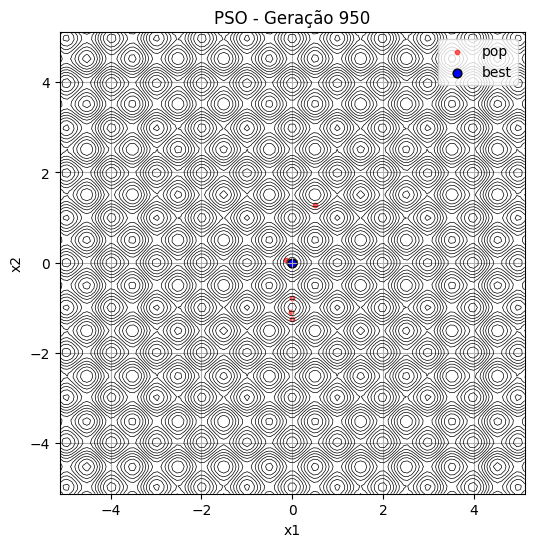


Tabela de Resultados:
   Execução  Convergiu  Gerações  Melhor f(x)
0         1      False       999     3.979836
1         2      False       999     1.989918
2         3       True       846     0.000900
3         4      False       999     1.989918
4         5       True       800     0.000677
5         6      False       999     0.994959
6         7       True       681     0.000770
7         8       True       689     0.000611
8         9      False       999     0.994959
9        10      False       999     0.994959

--- Estatísticas ---
Taxa de sucesso: 40.0%
Melhor valor: 0.000611
Média: 1.094751


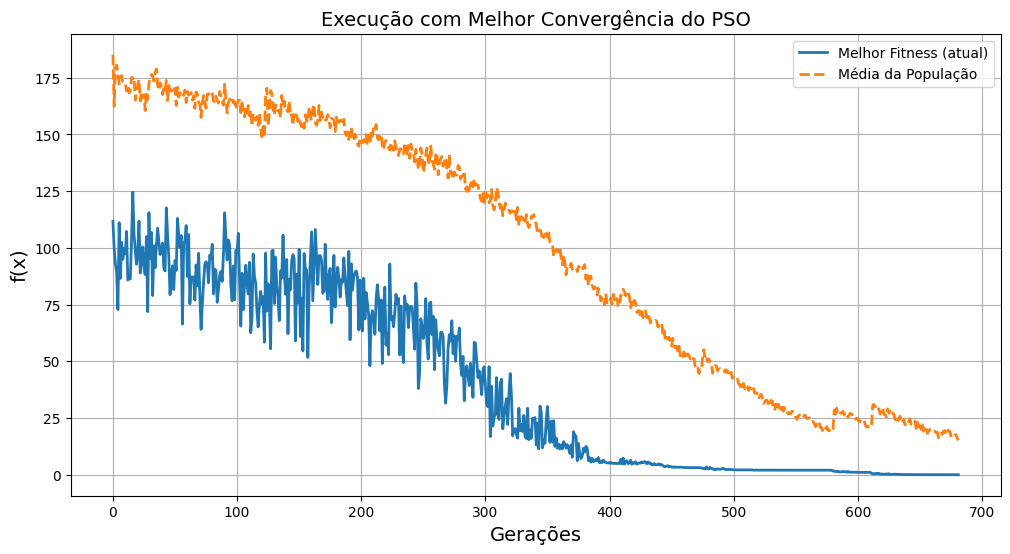

In [39]:
n_runs = 10
results = []
histories = []

for run in range(n_runs):
    print(f"\nExecução {run+1}/{n_runs}")

    best_hist, avg_hist, final_pop, n_gen, converged, gbest, gbest_fit = pso()

    results.append({
        "Execução": run + 1,
        "Convergiu": converged,
        "Gerações": n_gen,
        "Melhor f(x)": gbest_fit  
    })

    histories.append({
        "best": best_hist,
        "avg": avg_hist,
        "gen": n_gen,
        "best_value": gbest_fit,
        "converged": converged
    })

df = pd.DataFrame(results)
print("\nTabela de Resultados:")
print(df)

success_rate = df["Convergiu"].mean()
best_overall = df["Melhor f(x)"].min()
mean_value = df["Melhor f(x)"].mean()

print("\n--- Estatísticas ---")
print(f"Taxa de sucesso: {success_rate*100:.1f}%")
print(f"Melhor valor: {best_overall:.6f}")
print(f"Média: {mean_value:.6f}")

valid_runs = [h for h in histories if h["converged"]]
if len(valid_runs) > 0:
    best_run = min(valid_runs, key=lambda x: x["gen"])
else:
    best_run = min(histories, key=lambda x: x["best_value"])

plt.figure(figsize=(12,6))
plt.plot(best_run["best"], label="Melhor Fitness (atual)", linewidth=2)
plt.plot(best_run["avg"], label="Média da População", linestyle='--', linewidth=2)
plt.xlabel("Gerações", fontsize=14)
plt.ylabel("f(x)", fontsize=14)
plt.title("Execução com Melhor Convergência do PSO", fontsize=14)
plt.legend()
plt.grid()
plt.show()
